In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from config.settings import DATA_DIR

### 1. Observational data

https://simbad.u-strasbg.fr/simbad/sim-basic?Ident=PSR+J2030+%2B4415&submit=SIMBAD+search

RA: 20 30 51.396

DEC: +44 15 38.73

GLON: 082.340409

GLAT: +02.885411

!!! MIGHT BE POINT-LIKE SOURCE IN FERMI (OR EVEN NON-POINT LIKE)

SEEN BY CHANDRA, NOT SEEN BY XMM-NEWTON

Pulsar:

$\dot{E} = 2.4\times10^{34}\,\mathrm{erg/s}$ 

$\tau_c = 555~\mathrm{kyr}$

#### 1.1. **Chandra Spectrum** [Dinsmore, Romani, 2024]

In [2]:
data = pd.read_csv(f"{DATA_DIR}/j2030/spectrum.csv")
data.head()

,energy,Flux,Type,Label
0,0.885705,3.246561e-15,0,Data
1,0.885705,9.799697e-15,0,Upper
2,0.885705,1.008126e-16,0,Lower
3,0.966440,1.110949e-16,1,Data
4,0.968275,5.276183e-15,1,Upper


In [3]:
data_data = (data[data["Label"] == "Data"][["energy", "Flux"]]).reset_index(drop=True)
data_upper = (data[data["Label"] == "Upper"][["Flux"]]).reset_index(drop=True)
data_lower = (data[data["Label"] == "Lower"][["Flux"]]).reset_index(drop=True)

In [4]:
data_data["Upper"] = data_upper["Flux"] 
data_data["Lower"] = data_lower["Flux"]

flux = data_data
flux.head()

,energy,Flux,Upper,Lower
0,0.885705,3.246561e-15,9.799697e-15,1.008126e-16
1,0.966440,1.110949e-16,5.276183e-15,1.008126e-16
2,1.056537,4.730077e-15,9.001312e-15,4.826758e-16
3,1.152845,9.681446e-15,1.311446e-14,6.407349e-15
4,1.260319,5.340627e-15,7.781027e-15,2.875408e-15


In [5]:
flux["Flux"] = flux["Flux"] * flux["energy"]
flux["Upper"] = flux["Upper"] * flux["energy"]
flux["Lower"] = flux["Lower"] * flux["energy"]

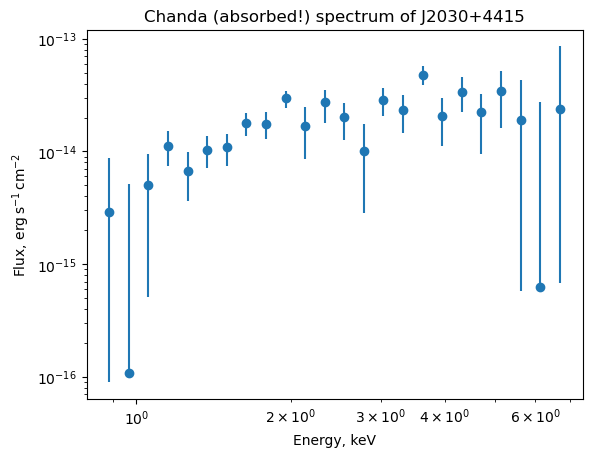

In [9]:
plt.errorbar(flux.energy, flux.Flux, yerr=[flux.Flux - flux.Lower, flux.Upper - flux.Flux], fmt='o')
plt.title("Chanda (absorbed!) spectrum of J2030+4415")
plt.xscale('log')
plt.xlabel("Energy, keV")
plt.yscale('log')
plt.ylabel(r"Flux, $\mathrm{erg\,s^{-1}\,cm^{-2}}$")
plt.show()